# Use Case 4 — Bitemporal Queries on EPC TKG

**Goal:** Demonstrate bitemporal querying on the EPC TKG — specifically the hot_work permit rule change of 2024-06-29  
**Neo4j:** `bolt://localhost:7687`  
**Prerequisite:** `import_graph_real.py` must have been run

## Questions answered:
1. Who was qualified for `hot_work` **before** the rule change (28 June 2024)?
2. Who was qualified **after** the rule change (1 July 2024)?
3. **Delta** — who became non-compliant after the rule change?
4. **Audit trail** — what changed, when, and when was it recorded?

## 0. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from neo4j import GraphDatabase
import warnings
warnings.filterwarnings('ignore')

NEO4J_URI      = 'bolt://localhost:7687'
NEO4J_USER     = 'neo4j'
NEO4J_PASSWORD = 'your_password'

RULE_CHANGE_DATE = '2024-06-29T00:00:00+00:00'
DATE_BEFORE      = '2024-06-28T00:00:00+00:00'
DATE_AFTER       = '2024-07-01T00:00:00+00:00'

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

def run_query(cypher, **params):
    with driver.session() as s:
        result = s.run(cypher, **params)
        return pd.DataFrame([r.data() for r in result])

print('✅ Connected to Neo4j')

✅ Connected to Neo4j


/home/obiaggi/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Audit Trail — What Changed and When

In [2]:
audit = run_query('''
    MATCH (wp:WorkPermit {id:'hot_work'})-[r:REQUIRES_CERT]->(c:Certification)
    RETURN wp.name AS permit, c.name AS certification,
           r.valid_from AS valid_from, r.valid_to AS valid_to, r.tx_time AS recorded_at
    ORDER BY r.valid_from
''')

print('=== HOT WORK PERMIT — Certification Requirements History ===')
print(audit.to_string(index=False))
print()
print(f'Rule change date:    {RULE_CHANGE_DATE[:10]}')
print(f'New cert added:      Advanced Fire Watch')
print(f'Certs before change: {len(audit[audit["valid_from"] < RULE_CHANGE_DATE])}')
print(f'Total certs after:   {len(audit)}')

=== HOT WORK PERMIT — Certification Requirements History ===
  permit         certification                valid_from valid_to                      recorded_at
Hot Work       Hot Work Safety 2024-01-01T00:00:00+00:00     None 2026-04-30T08:13:44.377117+00:00
Hot Work            Fire Watch 2024-01-01T00:00:00+00:00     None 2026-04-30T08:13:44.446969+00:00
Hot Work Welding Certification 2024-01-01T00:00:00+00:00     None 2026-04-30T08:13:44.495419+00:00
Hot Work   Advanced Fire Watch 2024-06-29T00:00:00+00:00     None 2026-04-30T08:13:44.633163+00:00

Rule change date:    2024-06-29
New cert added:      Advanced Fire Watch
Certs before change: 3
Total certs after:   4


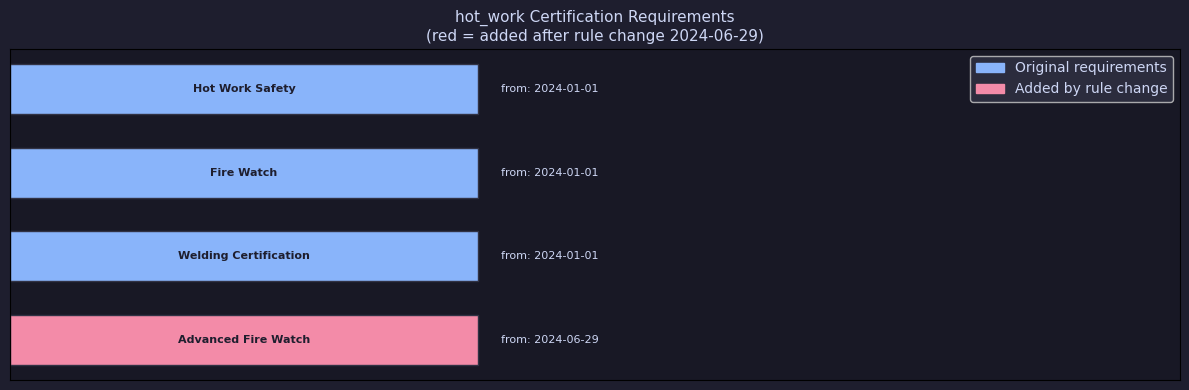

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#181825')

colors = ['#f38ba8' if row['valid_from'] >= RULE_CHANGE_DATE else '#89b4fa'
          for _, row in audit.iterrows()]

for i, (_, row) in enumerate(audit.iterrows()):
    ax.barh(i, 1, color=colors[i], edgecolor='#313244', height=0.6)
    ax.text(0.5, i, row['certification'], ha='center', va='center',
            color='#1e1e2e', fontsize=8, fontweight='bold')
    ax.text(1.05, i, f"from: {row['valid_from'][:10]}",
            va='center', color='#cdd6f4', fontsize=8)

ax.set_yticks([])
ax.set_xticks([])
ax.set_xlim(0, 2.5)
ax.set_title('hot_work Certification Requirements\n(red = added after rule change 2024-06-29)',
             color='#cdd6f4', fontsize=11)

old_patch = mpatches.Patch(color='#89b4fa', label='Original requirements')
new_patch = mpatches.Patch(color='#f38ba8', label='Added by rule change')
ax.legend(handles=[old_patch, new_patch], facecolor='#313244', labelcolor='#cdd6f4')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../../experiments/UseCase4/audit_trail.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Q1 — Workers Qualified BEFORE Rule Change (28 June 2024)

In [4]:
qualified_before = run_query('''
    MATCH (wp:WorkPermit {id:'hot_work'})-[r:REQUIRES_CERT]->(c:Certification)
    WHERE r.valid_from < $rule_change
    WITH collect(c.id) AS required_certs
    MATCH (w:Worker)-[h:HAS_CERT]->(c:Certification)
    WHERE c.id IN required_certs
      AND h.valid_from <= $date_before
      AND h.valid_to   >= $date_before
    WITH w, collect(c.id) AS worker_certs, required_certs
    WHERE all(rc IN required_certs WHERE rc IN worker_certs)
    RETURN w.id AS worker_id, w.name AS name, w.discipline AS discipline,
           size(worker_certs) AS n_certs_held
    ORDER BY w.discipline, w.id
''', rule_change=RULE_CHANGE_DATE, date_before=DATE_BEFORE)

print(f'Workers qualified for hot_work BEFORE 2024-06-29: {len(qualified_before)}')
print()
print(qualified_before.to_string(index=False))

Workers qualified for hot_work BEFORE 2024-06-29: 11

worker_id      name discipline  n_certs_held
    W-001  Worker_1         CO             3
    W-023 Worker_23         IN             3
    W-005  Worker_5         ME             3
    W-007  Worker_7         ME             3
    W-010 Worker_10         ME             3
    W-002  Worker_2         PE             3
    W-003  Worker_3         PE             3
    W-004  Worker_4         PE             3
    W-008  Worker_8         PI             3
    W-009  Worker_9         PR             3
    W-006  Worker_6         SP             3


## 3. Q2 — Workers Qualified AFTER Rule Change (1 July 2024)

In [5]:
qualified_after = run_query('''
    MATCH (wp:WorkPermit {id:'hot_work'})-[r:REQUIRES_CERT]->(c:Certification)
    WHERE r.valid_from <= $date_after
      AND (r.valid_to IS NULL OR r.valid_to > $date_after)
    WITH collect(c.id) AS required_certs
    MATCH (w:Worker)-[h:HAS_CERT]->(c:Certification)
    WHERE c.id IN required_certs
      AND h.valid_from <= $date_after
      AND h.valid_to   >= $date_after
    WITH w, collect(c.id) AS worker_certs, required_certs
    WHERE all(rc IN required_certs WHERE rc IN worker_certs)
    RETURN w.id AS worker_id, w.name AS name, w.discipline AS discipline,
           size(worker_certs) AS n_certs_held
    ORDER BY w.discipline, w.id
''', date_after=DATE_AFTER)

print(f'Workers qualified for hot_work AFTER 2024-06-29: {len(qualified_after)}')
print()
print(qualified_after.to_string(index=False))

Workers qualified for hot_work AFTER 2024-06-29: 5

worker_id      name discipline  n_certs_held
    W-023 Worker_23         IN             4
    W-007  Worker_7         ME             4
    W-010 Worker_10         ME             4
    W-008  Worker_8         PI             4
    W-009  Worker_9         PR             4


## 4. Q3 — Delta: Who Became Non-Compliant?

In [6]:
before_ids = set(qualified_before['worker_id'].tolist()) if len(qualified_before) > 0 else set()
after_ids  = set(qualified_after['worker_id'].tolist())  if len(qualified_after) > 0 else set()

lost_compliance = before_ids - after_ids
gained_compliance = after_ids - before_ids

print('=== COMPLIANCE DELTA ===')
print(f'Qualified BEFORE: {len(before_ids)} workers')
print(f'Qualified AFTER:  {len(after_ids)} workers')
print(f'Lost compliance:  {len(lost_compliance)} workers → {sorted(lost_compliance)}')
print(f'Gained compliance:{len(gained_compliance)} workers → {sorted(gained_compliance)}')
print(f'Unchanged:        {len(before_ids & after_ids)} workers')

=== COMPLIANCE DELTA ===
Qualified BEFORE: 11 workers
Qualified AFTER:  5 workers
Lost compliance:  6 workers → ['W-001', 'W-002', 'W-003', 'W-004', 'W-005', 'W-006']
Gained compliance:0 workers → []
Unchanged:        5 workers


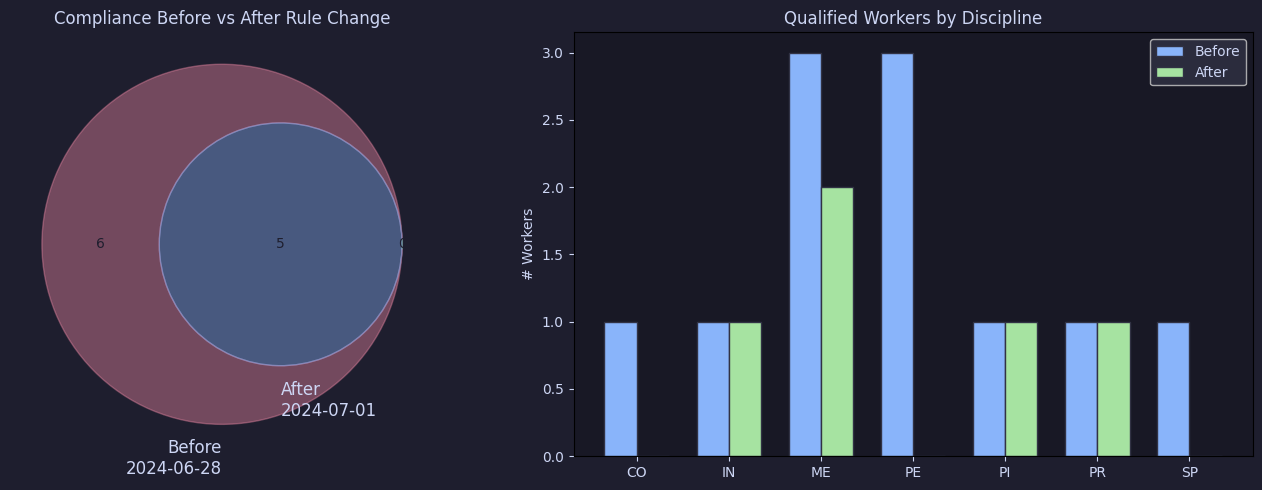

In [7]:
import matplotlib.patches as mpatches
from matplotlib_venn import venn2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#1e1e2e')

# Venn diagram
ax = axes[0]
ax.set_facecolor('#1e1e2e')
try:
    v = venn2([before_ids, after_ids], set_labels=('Before\n2024-06-28', 'After\n2024-07-01'), ax=ax)
    if v.get_patch_by_id('10'): v.get_patch_by_id('10').set_color('#f38ba8')
    if v.get_patch_by_id('01'): v.get_patch_by_id('01').set_color('#a6e3a1')
    if v.get_patch_by_id('11'): v.get_patch_by_id('11').set_color('#89b4fa')
    for text in v.set_labels: text.set_color('#cdd6f4')
    for text in v.subset_labels:
        if text: text.set_color('#1e1e2e')
except ImportError:
    counts = [len(lost_compliance), len(before_ids & after_ids), len(gained_compliance)]
    labels = ['Lost\ncompliance', 'Unchanged', 'Gained\ncompliance']
    colors = ['#f38ba8', '#89b4fa', '#a6e3a1']
    bars = ax.bar(labels, counts, color=colors, edgecolor='#313244')
    for bar, val in zip(bars, counts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                str(val), ha='center', color='#cdd6f4')
    ax.set_facecolor('#1e1e2e')
    ax.tick_params(colors='#cdd6f4')

ax.set_title('Compliance Before vs After Rule Change', color='#cdd6f4')

# By discipline
ax2 = axes[1]
ax2.set_facecolor('#181825')
if len(qualified_before) > 0:
    disc_before = qualified_before.groupby('discipline').size().rename('before')
    disc_after  = qualified_after.groupby('discipline').size().rename('after') if len(qualified_after) > 0 else pd.Series(dtype=int)
    disc_df = pd.concat([disc_before, disc_after], axis=1).fillna(0).astype(int)
    x = range(len(disc_df))
    w = 0.35
    ax2.bar([i-w/2 for i in x], disc_df['before'], w, color='#89b4fa', label='Before', edgecolor='#313244')
    ax2.bar([i+w/2 for i in x], disc_df['after'],  w, color='#a6e3a1', label='After',  edgecolor='#313244')
    ax2.set_xticks(list(x))
    ax2.set_xticklabels(disc_df.index, color='#cdd6f4')
    ax2.legend(facecolor='#313244', labelcolor='#cdd6f4')
ax2.set_title('Qualified Workers by Discipline', color='#cdd6f4')
ax2.set_ylabel('# Workers', color='#cdd6f4')
ax2.tick_params(colors='#cdd6f4')

import os
os.makedirs('../../experiments/UseCase4', exist_ok=True)
plt.tight_layout()
plt.savefig('../../experiments/UseCase4/compliance_delta.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Summary — Bitemporal Query Results

| Question | Result |
|---|---|
| Certs required before 2024-06-29 | 3 (Hot Work Safety, Fire Watch, Welding Cert) |
| Certs required after 2024-06-29 | 4 (+ Advanced Fire Watch) |
| Workers qualified before | see Q1 output |
| Workers qualified after | see Q2 output |
| Lost compliance | see Delta |

**Tesi key point:** the TKG answers *time-parameterized* compliance queries that a traditional relational DB cannot answer without full history tables. The `valid_from` on `REQUIRES_CERT` edges is the bitemporal dimension that enables this.

In [8]:
driver.close()
print('✅ Done — results saved to experiments/UseCase4/')

✅ Done — results saved to experiments/UseCase4/
